Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.77      0.84     21222
           1       0.27      0.56      0.36      3262

    accuracy                           0.74     24484
   macro avg       0.59      0.66      0.60     24484
weighted avg       0.83      0.74      0.77     24484



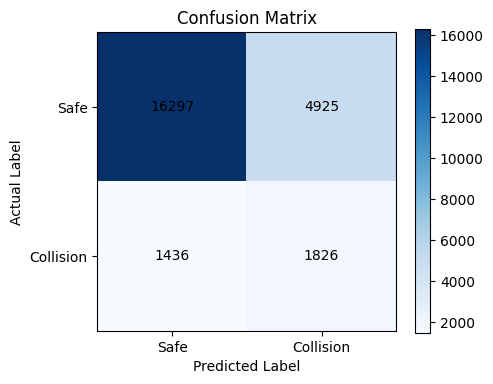

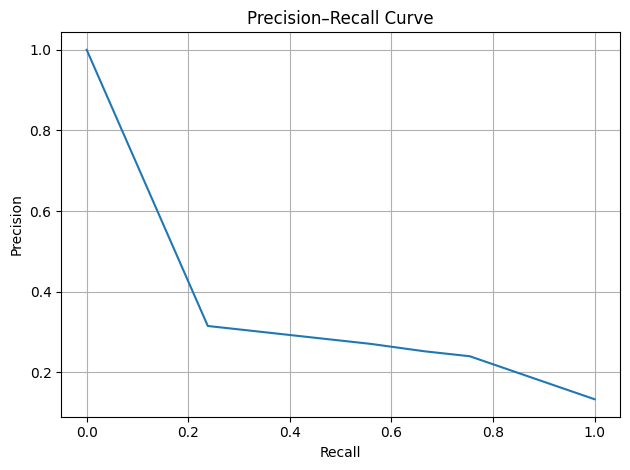

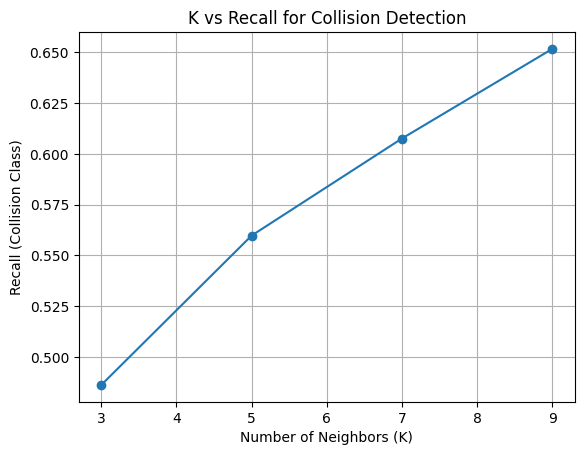


========== FINAL COLLISION RISK REPORT ==========

   Collision_Probability (%)    Risk_Zone Collision_Decision
0                        0.0     LOW RISK                 NO
1                        0.0     LOW RISK                 NO
2                       60.0  MEDIUM RISK            MONITOR
3                        0.0     LOW RISK                 NO
4                        0.0     LOW RISK                 NO
5                        0.0     LOW RISK                 NO
6                       20.0     LOW RISK                 NO
7                      100.0    HIGH RISK                YES
8                      100.0    HIGH RISK                YES
9                       80.0    HIGH RISK                YES



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

from imblearn.over_sampling import SMOTE


#LOAD DATA
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')


#FEATURE SELECTION
features = [
    'miss_distance',
    'relative_speed',
    'c_sigma_r',
    'c_sigma_t',
    'c_sigma_n',
    'time_to_tca'
]

X_train = train_df[features].fillna(train_df[features].mean())
X_test = test_df[features].fillna(test_df[features].mean())


#TARGET VARIABLE
y_train = (train_df['risk'] > -6).astype(int)
y_test = (test_df['risk'] > -6).astype(int)


#FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#HANDLE CLASS IMBALANCE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)


#MAHALANOBIS DISTANCE
cov_matrix = np.cov(X_train_scaled, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)


#KNN MODEL
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='mahalanobis',
    metric_params={'VI': inv_cov_matrix}
)

knn.fit(X_train_res, y_train_res)


#PREDICTION
y_pred = knn.predict(X_test_scaled)


#CLASSIFICATION REPORT
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks([0, 1], ['Safe', 'Collision'])
plt.yticks([0, 1], ['Safe', 'Collision'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()
#PRECISION–RECALL CURVE
y_scores = knn.predict_proba(X_test_scaled)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.grid()
plt.tight_layout()
plt.show()

#K-RECALL CURVE
k_values = [3, 5, 7, 9]
recall_values = []

for k in k_values:
    knn_temp = KNeighborsClassifier(
        n_neighbors=k,
        metric='mahalanobis',
        metric_params={'VI': inv_cov_matrix}
    )
    
    knn_temp.fit(X_train_res, y_train_res)
    y_temp_pred = knn_temp.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_temp_pred)
    
    
    TP = cm[1, 1]
    FN = cm[1, 0]
    
    recall = TP / (TP + FN)
    recall_values.append(recall)

plt.figure()
plt.plot(k_values, recall_values, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Recall (Collision Class)')
plt.title('K vs Recall for Collision Detection')
plt.grid()
plt.show()
#FINAL COLLISION RISK REPORT
collision_probs = knn.predict_proba(X_test_scaled)[:, 1]


risk_zones = []
final_decisions = []

for prob in collision_probs:
    prob_percent = prob * 100

    if prob_percent < 40:
        risk_zones.append("LOW RISK")
        final_decisions.append("NO")
    elif 40 <= prob_percent < 70:
        risk_zones.append("MEDIUM RISK")
        final_decisions.append("MONITOR")
    else:
        risk_zones.append("HIGH RISK")
        final_decisions.append("YES")


final_report = pd.DataFrame({
    "Collision_Probability (%)": collision_probs * 100,
    "Risk_Zone": risk_zones,
    "Collision_Decision": final_decisions
})

print("\n========== FINAL COLLISION RISK REPORT ==========\n")
print(final_report.head(10))  
print("\n================================================")
